In [37]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [38]:
import jax
import jax.numpy as jnp
from liesel_ptm.sim.create_data import generate_data, loc_fn, scale_fn, generate_show_data
import liesel_ptm.sim.sim_ptm_onion as sim
import liesel.goose as gs

import liesel_ptm as ptm
import plotnine as p9
import pandas as pd
import matplotlib.pyplot as plt

In [39]:
key = jax.random.PRNGKey(43)
k1, k2, k3 = jax.random.split(key, 3)
shape = ptm.sample_shape(k1, nshape=15, scale=0.5).sample

In [40]:
df = generate_data(k2, shape=shape, nobs=2000, loc_fn=loc_fn, scale_fn=scale_fn, ncov=4)
df_show = generate_show_data(shape=shape, values=(-1.0, 0.0, 1.0), index=3, loc_fn=loc_fn, scale_fn=scale_fn, ncov=4)


In [41]:
df_test = generate_data(k3, shape=shape, nobs=500, loc_fn=loc_fn, scale_fn=scale_fn, ncov=4)

In [42]:
df.head()

,y,y_std,z,z_deriv,log_prob,pdf,cdf,loc,scale,std_log_prob,...,fx2_loc,fx3_loc,fx0_scale,fx1_scale,fx2_scale,fx3_scale,x0,x1,x2,x3
0,2.484740,-0.653952,-0.512790,1.568241,-0.600460,0.548559,0.304049,3.542881,1.618070,-0.119226,...,-0.082664,0.555224,1.269459,-0.576595,-0.029371,0.249834,1.269459,-1.398751,-0.021741,-0.383004
1,1.649830,-0.912382,-1.338562,2.902153,-0.749358,0.472670,0.090357,2.839185,1.303571,-0.484251,...,0.837539,-2.863342,-0.188113,2.090443,0.297587,-1.288418,-0.188113,1.543578,0.834372,-1.575229
2,5.530048,-0.410966,-0.042404,0.638596,-1.368321,0.254534,0.483090,6.435397,2.202976,-0.578512,...,-0.929368,3.868842,1.462696,-0.386041,-0.330215,1.740862,1.462696,0.221004,-0.120351,0.207599
3,-1.207294,-1.002481,-1.690612,4.440330,-0.857292,0.424309,0.045456,-0.302614,0.902442,-0.959944,...,-2.081064,0.300538,-0.723898,-0.247792,-0.739426,0.135233,-0.723898,-1.715694,-0.289747,-0.417014
4,2.361541,0.802402,0.870754,0.159386,-3.134472,0.043523,0.808056,1.350146,1.260460,-2.902996,...,-4.100655,2.955674,0.964619,-0.798302,-1.457010,1.329964,0.964619,-1.053753,1.706341,0.525832


In [43]:
df_show.head()

,y,y_std,z,z_deriv,log_prob,pdf,cdf,loc,scale,std_log_prob,std_pdf,x0,x1,x2,x3
0,-2.192809,-1.781953,-4.000000,2.696191,-7.927097,0.000361,0.000032,-0.497307,0.951486,-7.976828,0.000343,0.0,0.0,0.0,-1.0
1,-2.177814,-1.766193,-3.959799,2.664938,-7.778734,0.000419,0.000038,-0.497307,0.951486,-7.828465,0.000398,0.0,0.0,0.0,-1.0
2,-2.162625,-1.750230,-3.919598,2.627469,-7.634546,0.000483,0.000044,-0.497307,0.951486,-7.684277,0.000460,0.0,0.0,0.0,-1.0
3,-2.147199,-1.734017,-3.879397,2.583364,-7.494708,0.000556,0.000052,-0.497307,0.951486,-7.544438,0.000529,0.0,0.0,0.0,-1.0
4,-2.131486,-1.717503,-3.839196,2.532285,-7.359506,0.000637,0.000062,-0.497307,0.951486,-7.409236,0.000606,0.0,0.0,0.0,-1.0


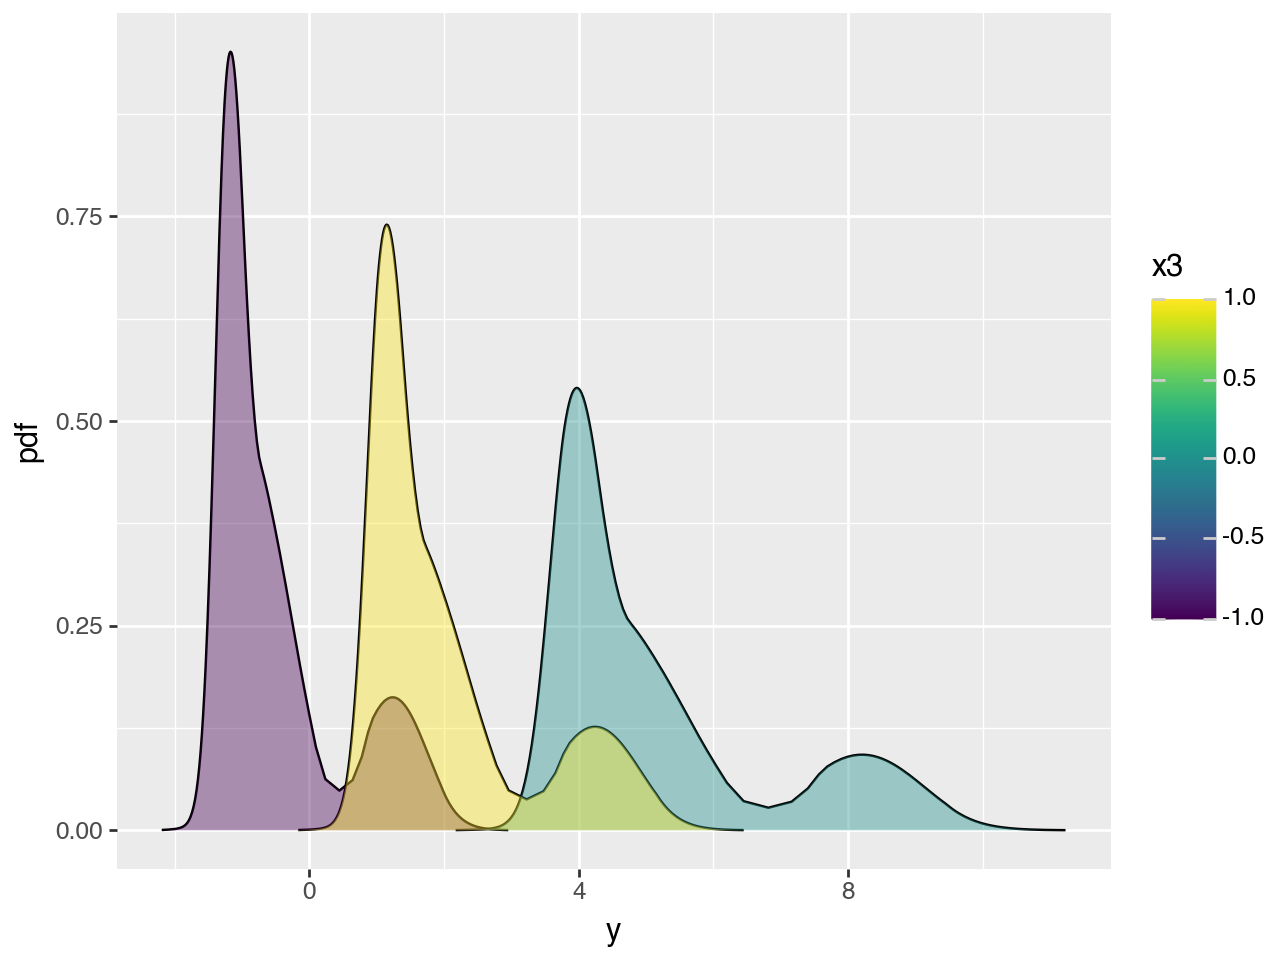

In [44]:
(
    p9.ggplot(df_show)
    + p9.aes("y", "pdf", group="x3")
    + p9.geom_line()
    + p9.geom_ribbon(p9.aes(ymin=0.0, ymax="pdf", fill="x3"), alpha=0.4)
)

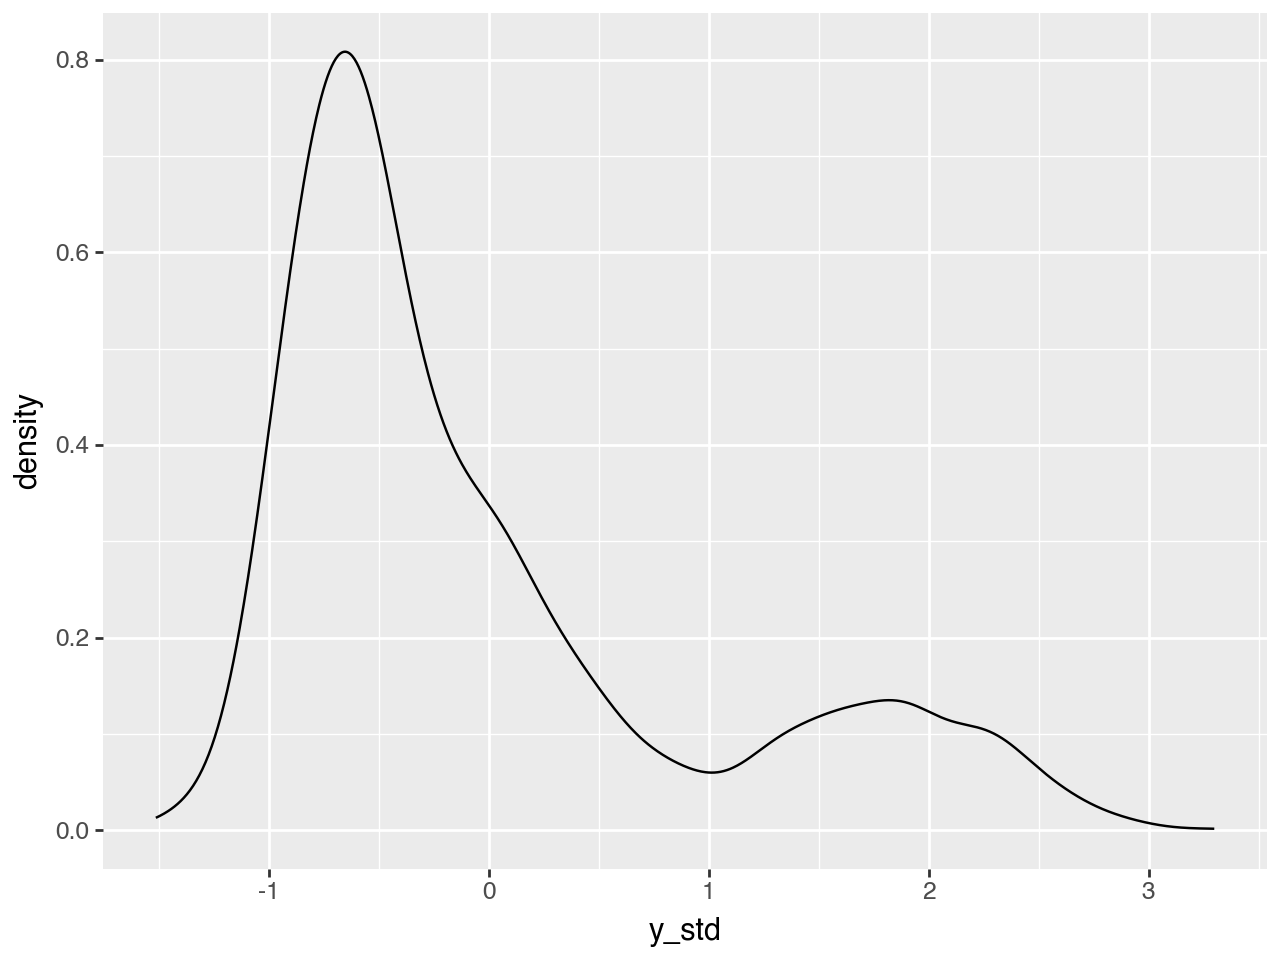

In [45]:
(
    p9.ggplot(df)
    + p9.aes("y_std")
    + p9.geom_density()
)

In [46]:
model = sim.model_setup(
    df, 
    prior_tau2_covariates=(ptm.VarInverseGamma, {"value": 1.0, "concentration": 1.0, "scale":0.01}),
    prior_tau2_normalization=(ptm.VarHalfCauchy, {"value": 1.0, "scale": 0.05}),
    scale_terms=True,
    nshape=30,
    centered=True,
    scaled=True
)

liesel_ptm.model - INFO - Optimizing location and scale parameters.
liesel_ptm.model - INFO - Building model graph. No changes to the model can be made after this step.
Training loss: 3141.325, Validation loss: 3141.324:   9%|▉         | 900/9999 [00:39<03:42, 40.89it/s] liesel_ptm.model - INFO - Optimizing location and scale parameters finished after 900 iterations.


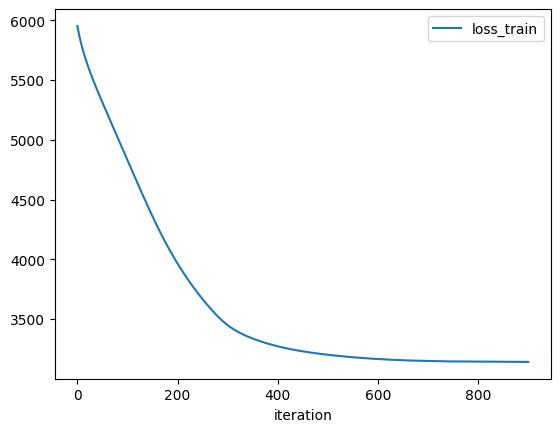

In [47]:
res1a = model.optimize_locscale(patience=10, max_iter=10_000)
ptm.history_to_df(res1a.history)[["loss_train", "iteration"]].plot("iteration")
plt.show()

In [48]:
res1b = res1a

In [49]:
# res1b = model.optimize_locscale(patience=10, max_iter=10_000, include_loc=False)
# ptm.history_to_df(res1b.history)[["loss_train", "iteration"]].plot("iteration")
# plt.show()

In [50]:
res2 = model.optimize_transformation(patience=100, max_iter=10_000)

liesel_ptm.model - INFO - Optimizing transformation parameters.
Training loss: 2470.848, Validation loss: 2470.848:  28%|██▊       | 2846/9999 [01:38<02:55, 40.79it/s] liesel_ptm.model - INFO - Optimizing transformation parameters finished after 2846 iterations.


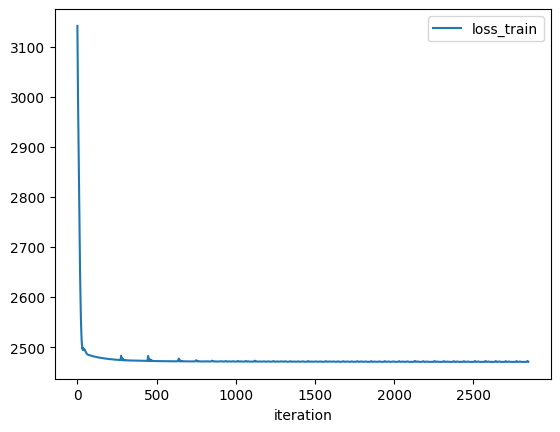

In [51]:
ptm.history_to_df(res2.history)[["loss_train", "iteration"]].plot("iteration")
plt.show()

In [52]:
mdist = model.init_dist(res1a.position | res1b.position | res2.position)
res, _ = mdist.transformation_and_logdet_parametric(model.response.value)

liesel_ptm.model - INFO - Fixed value of x0_loc to corresponding node value.
liesel_ptm.model - INFO - Fixed value of x1_loc to corresponding node value.
liesel_ptm.model - INFO - Fixed value of x2_loc to corresponding node value.
liesel_ptm.model - INFO - Fixed value of x3_loc to corresponding node value.
liesel_ptm.model - INFO - Fixed value of x0_scale to corresponding node value.
liesel_ptm.model - INFO - Fixed value of x1_scale to corresponding node value.
liesel_ptm.model - INFO - Fixed value of x2_scale to corresponding node value.
liesel_ptm.model - INFO - Fixed value of x3_scale to corresponding node value.
liesel_ptm.model - INFO - Fixed value of normalization_tau2_root_transformed to corresponding node value.
liesel_ptm.model - INFO - Fixed value of x0_loc to corresponding node value.
liesel_ptm.model - INFO - Fixed value of x1_loc to corresponding node value.
liesel_ptm.model - INFO - Fixed value of x2_loc to corresponding node value.
liesel_ptm.model - INFO - Fixed value o

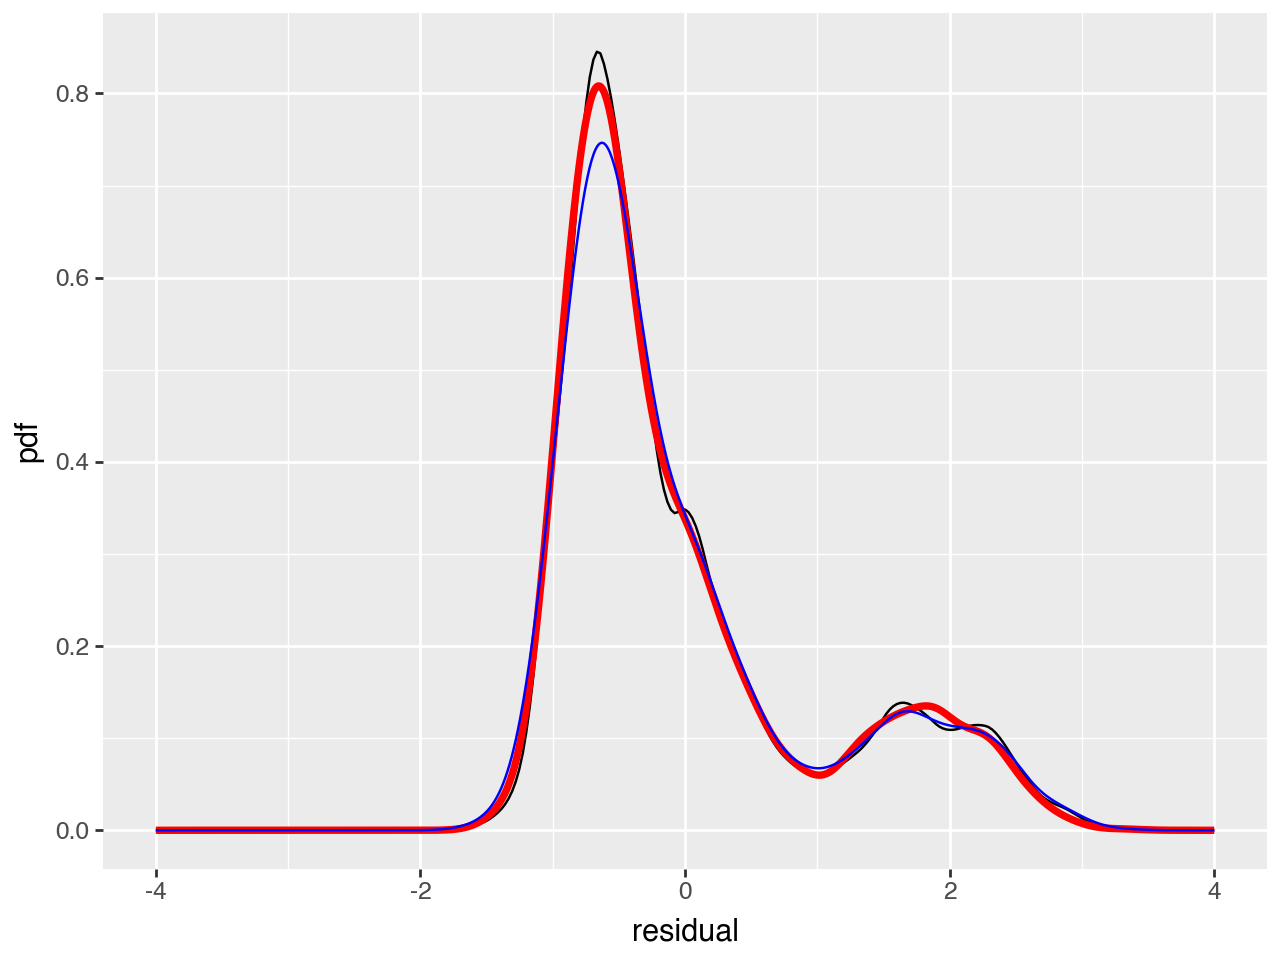

In [53]:
dist = model.dist_class(model.knots.knots, model.coef.value, loc=0.0, scale=1.0)
residual = jnp.linspace(-4, 4, 301)
pdf = dist.prob(residual)
z, _ = dist.transformation_and_logdet(residual)



df_pdf = pd.DataFrame({"residual": residual, "pdf": pdf, "z": z})

(
    p9.ggplot(df_pdf)
    + p9.geom_line(p9.aes("residual", "pdf"))
    + p9.geom_density(p9.aes("y_std"), data = df, color="red", size=1.5)
    + p9.geom_density(
        p9.aes("res"),
        data=pd.DataFrame({"res": res}),
        color="blue"
    )
)

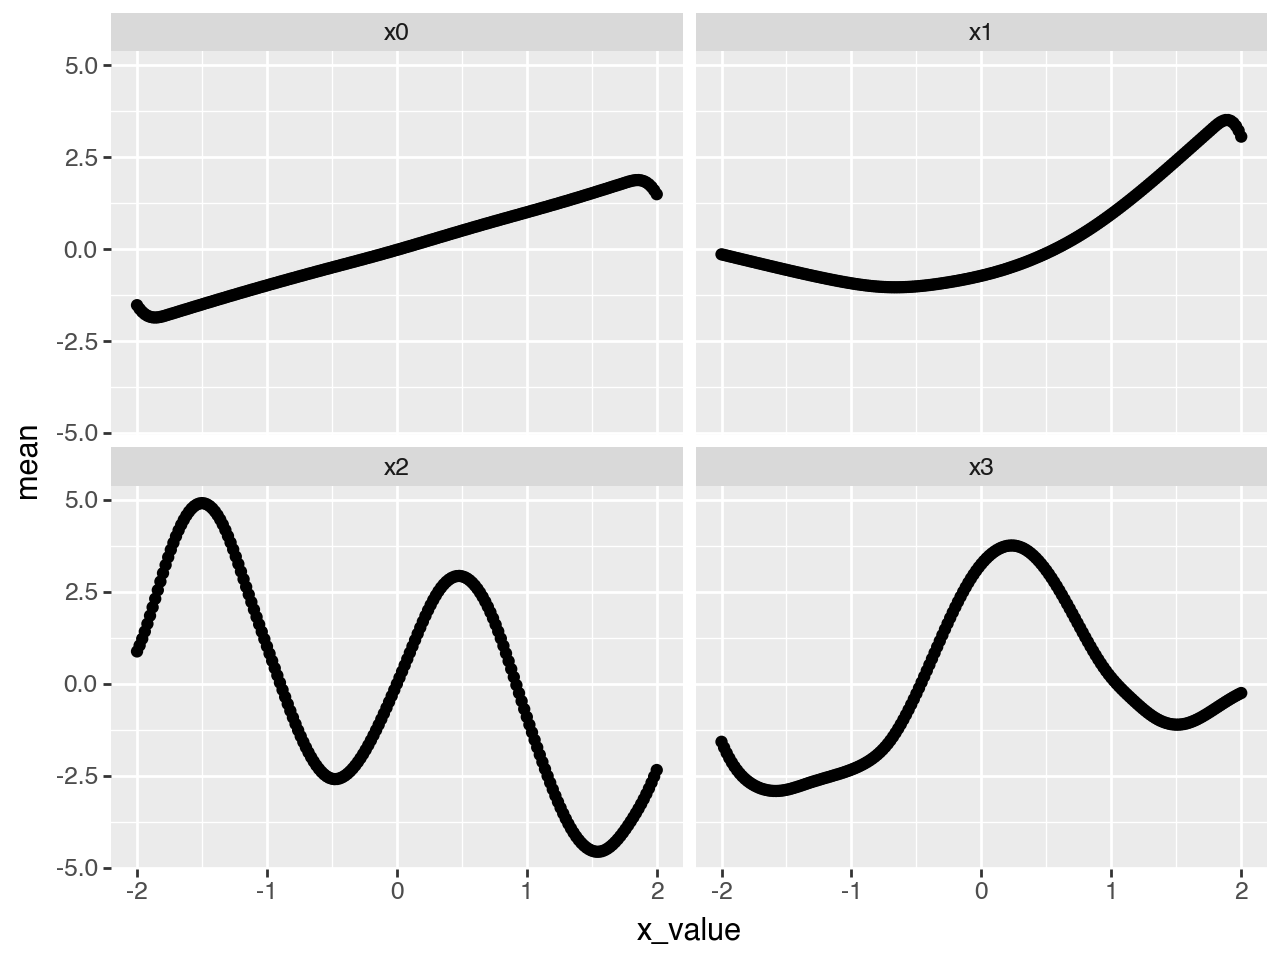

In [54]:
x0_loc = model.loc_model.x0_loc.summarise_by_quantiles(
    {"x0_loc_coef": jnp.expand_dims(res1a.position["x0_loc_coef"], 0)},
    x=jnp.linspace(-2, 2, 201),
    axis=0
)
x0_loc["x"] = "x0"

x1_loc = model.loc_model.x1_loc.summarise_by_quantiles(
    {"x1_loc_coef": jnp.expand_dims(res1a.position["x1_loc_coef"], 0)},
    x=jnp.linspace(-2, 2, 201),
    axis=0
)
x1_loc["x"] = "x1"

x2_loc = model.loc_model.x2_loc.summarise_by_quantiles(
    {"x2_loc_coef": jnp.expand_dims(res1a.position["x2_loc_coef"], 0)},
    x=jnp.linspace(-2, 2, 201),
    axis=0
)
x2_loc["x"] = "x2"

x3_loc = model.loc_model.x3_loc.summarise_by_quantiles(
    {"x3_loc_coef": jnp.expand_dims(res1a.position["x3_loc_coef"], 0)},
    x=jnp.linspace(-2, 2, 201),
    axis=0
)
x3_loc["x"] = "x3"

loc_df = pd.concat([x0_loc, x1_loc, x2_loc, x3_loc])

(
    p9.ggplot(loc_df)
    + p9.aes("x_value", "mean")
    + p9.geom_point()
    + p9.facet_wrap("~x")
)

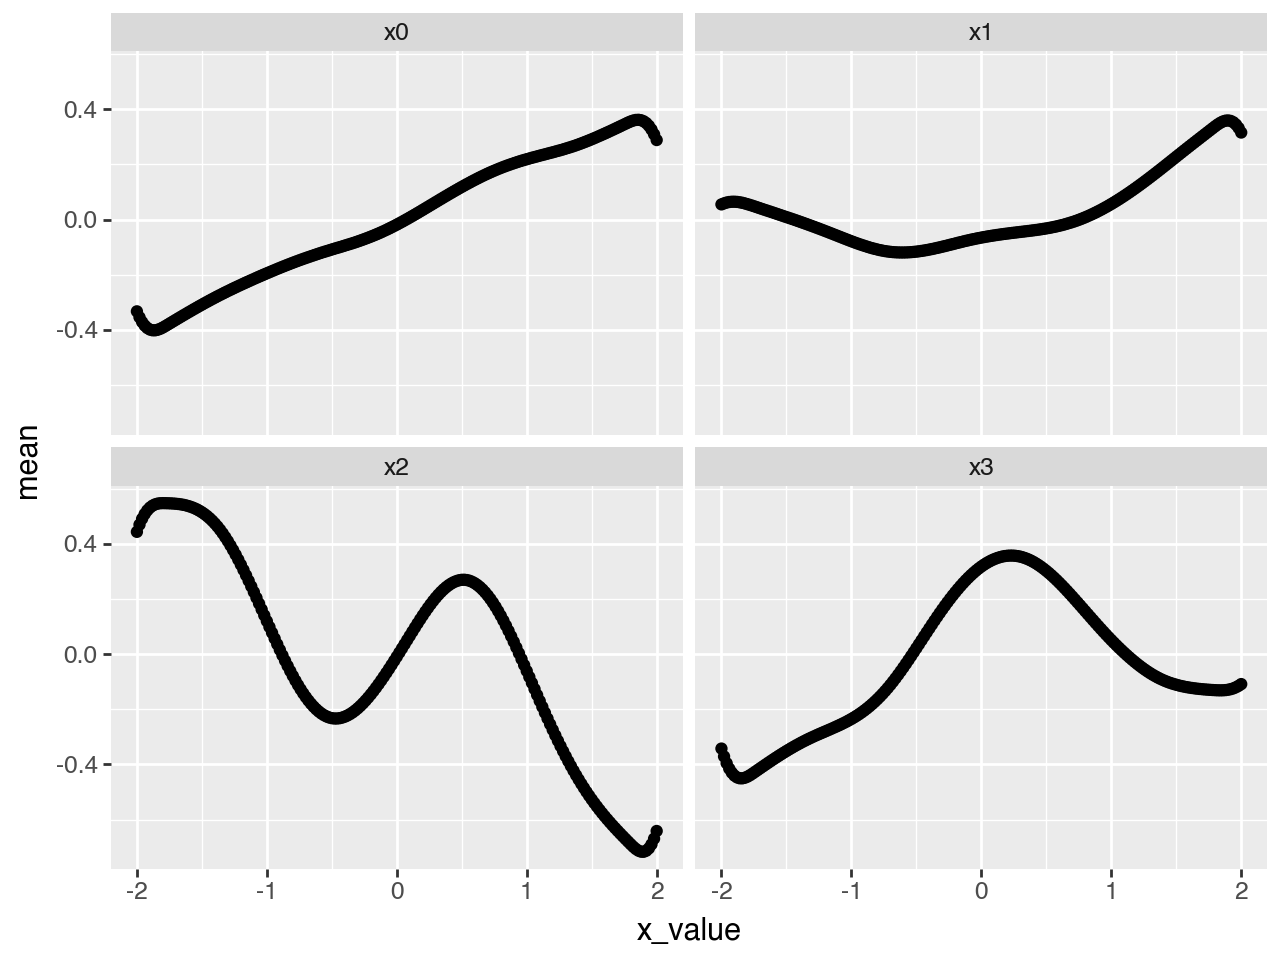

Training loss: 2470.848, Validation loss: 2470.848:  28%|██▊       | 2846/9999 [01:54<02:55, 40.79it/s]

In [55]:
x0_scale = model.log_scale_model.x0_scale.summarise_by_quantiles(
    {"x0_scale_coef": jnp.expand_dims(res1b.position["x0_scale_coef"], 0)},
    x=jnp.linspace(-2, 2, 201),
    axis=0
)
x0_scale["x"] = "x0"

x1_scale = model.log_scale_model.x1_scale.summarise_by_quantiles(
    {"x1_scale_coef": jnp.expand_dims(res1b.position["x1_scale_coef"], 0)},
    x=jnp.linspace(-2, 2, 201),
    axis=0
)
x1_scale["x"] = "x1"

x2_scale = model.log_scale_model.x2_scale.summarise_by_quantiles(
    {"x2_scale_coef": jnp.expand_dims(res1b.position["x2_scale_coef"], 0)},
    x=jnp.linspace(-2, 2, 201),
    axis=0
)
x2_scale["x"] = "x2"

x3_scale = model.log_scale_model.x3_scale.summarise_by_quantiles(
    {"x3_scale_coef": jnp.expand_dims(res1b.position["x3_scale_coef"], 0)},
    x=jnp.linspace(-2, 2, 201),
    axis=0
)
x3_scale["x"] = "x3"

scale_df = pd.concat([x0_scale, x1_scale, x2_scale, x3_scale])

(
    p9.ggplot(scale_df)
    + p9.aes("x_value", "mean")
    + p9.geom_point()
    + p9.facet_wrap("~x")
)